## 3. Model Eğitimi ve Seçimi (Model Training & Evaluation)

Bu notebook içerisinde, daha önce ön işlemesini tamamladığımız lojistik veri setimizi kullanarak bir "Gecikme Tahminleme Modeli" geliştiriyoruz. Amacımız, sevkiyatların gecikip gecikmeyeceğini (`Logistics_Delay`) yüksek doğrulukla tahmin edebilen bir yapay zeka mimarisi kurmak.

### İzleyeceğimiz Yol Haritası:
1. **Veri Ayrıştırma:** Veriyi Train/Test setlerine ayırarak modelin görülmemiş veri üzerindeki başarısını ölçeceğiz.
2. **Model Seçimi:** Gecikme tahmininde yüksek performans gösteren `RandomForest` ve `XGBoost` modellerini karşılaştıracağız.
3. **Cross-Validation:** Modelin veri setinin farklı bölümlerinde ne kadar kararlı çalıştığını test edeceğiz.
4. **Hiperparametre Optimizasyonu:** `GridSearchCV` ile modelin en iyi çalışma parametrelerini bulacağız.
5. **Model Değerlendirme:** Karmaşıklık matrisi (Confusion Matrix) ve ROC-AUC skorları ile modelin başarısını detaylı raporlayacağız.

In [2]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Kaydettiğimiz işlenmiş veriyi yüklüyoruz
data_path = os.path.join("..", "..", "..", "data", "processed", "processed_smart_logistics_dataset.csv")
df = pd.read_csv(data_path)

# Hedef değişken (Gecikme) ve bağımsız değişkenleri (Öznitelikler) ayırıyoruz
X = df.drop(columns=['Logistics_Delay'])
y = df['Logistics_Delay']

# Veriyi %80 Eğitim, %20 Test olarak ayırıyoruz. Rastgeleliği sabitleyerek her seferinde aynı ayrımı sağlıyoruz (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Sistem Bilgisi: Veri seti %80 Eğitim ve %20 Test olarak ayrıldı.")
print(f"Eğitim seti boyutu: {X_train.shape}, Test seti boyutu: {X_test.shape}")

Sistem Bilgisi: Veri seti %80 Eğitim ve %20 Test olarak ayrıldı.
Eğitim seti boyutu: (800, 14), Test seti boyutu: (200, 14)


## 3.1. Veri Ayrıştırma
Veri setimizi `train_test_split` fonksiyonu ile %80 eğitim ve %20 test olarak ayırdık. Özellikle `stratify=y` parametresini kullanarak, hem eğitim hem de test setindeki gecikme-zamanında teslimat oranlarının (sınıf dağılımlarının) orijinal veri setimizle aynı kalmasını sağladık. Bu, modelin test setinde yanlı sonuçlar vermesini (class imbalance bias) engellemek adına atılan en kritik adımdır.

## 3.2. Model Seçimi ve Baseline (Baz) Performans Ölçümü

Projemizde lojistik gecikme tahmini yapmak için iki farklı ağaç tabanlı model seçtik: **Random Forest** ve **XGBoost**.

### Neden Bu Modeller?
1. **Random Forest:** Lojistik gibi farklı kategorik (trafik durumu, hava durumu) ve sayısal verilerin iç içe olduğu yapılarda çok sağlamdır. Aşırı öğrenmeye (overfitting) karşı doğal bir direnci vardır ve mülakatlarda "kararlı tahmin" kapasitesini kanıtlamak için mükemmel bir baz (baseline) modeldir.
2. **XGBoost:** Otomotiv tedarik zinciri verisindeki gizli örüntüleri yakalamak için optimize edilmiş, gradyan tabanlı bir modeldir. Yüksek hızlı çıkarım (inference) yeteneği ve .NET entegrasyonuna uygunluğu ile projelerimizde yüksek doğruluk hedeflediğimiz nokta atışı modelimizdir.

Bu aşamada modellerimizi varsayılan (default) hiperparametrelerle eğitip, ilk "baz performans" skorlarımızı (Accuracy, ROC-AUC) ölçeceğiz.

In [5]:
# Modelleri tanımlıyoruz
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Modelleri eğitim setine fit ediyoruz
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Test seti üzerinde tahminleme yapıyoruz
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# İlk performans sonuçlarını alıyoruz
print("--- Random Forest Baseline Performans ---")
print(classification_report(y_test, rf_pred))
print("\n--- XGBoost Baseline Performans ---")
print(classification_report(y_test, xgb_pred))

--- Random Forest Baseline Performans ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- XGBoost Baseline Performans ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### Baseline Performans Analiz Yorumu
Elde ettiğimiz ilk sonuçlara göre (özellikle F1-Score ve Accuracy değerleri), hem `Random Forest` hem de `XGBoost` modellerinin lojistik verimiz üzerinde anlamlı bir öğrenme gerçekleştirdiği görülmektedir. 

*   **Random Forest yorumu:** Modelin "zamanında teslimat" ve "gecikme" sınıflarını ne kadar ayırabildiğini `classification_report` üzerinden analiz ediyoruz.
*   **XGBoost yorumu:** Eğer XGBoost'un baz performansı Random Forest'ın üzerindeyse, bu durum verimizdeki non-lineer (doğrusal olmayan) ilişkilerin gradyan artırımı (gradient boosting) ile daha iyi optimize edildiğini gösterir. 

Bu baz skorlar, hiperparametre optimizasyonu (GridSearchCV) ile ne kadar iyileştirme yapabileceğimizi belirlemek adına referans noktamız olacaktır.

## 3.3. Cross-Validation (Çapraz Doğrulama) ile Kararlılık Testi
Tek bir train-test ayrımı bazen şans eseri iyi veya kötü sonuçlar verebilir. Modelimizin performansının veri setinin geneline ne kadar "kararlı" olduğunu ölçmek için **K-Fold Cross-Validation** (k=5) yöntemini uyguluyoruz.

Bu yöntemle veriyi 5 parçaya bölüyoruz; modelimizi 4 parçada eğitip 1 parçasında test ediyoruz ve bu süreci 5 kez tekrarlıyoruz. Bu sayede modelimizin veri setinin her bir segmentinde ne kadar stabil çalıştığını sayısal olarak kanıtlıyoruz.

In [6]:
# Her iki model için 5-katlı çapraz doğrulama uyguluyoruz
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print(f"Random Forest 5-Fold CV Skorları: {rf_cv_scores}")
print(f"Random Forest Ortalama Doğruluk: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

print(f"\nXGBoost 5-Fold CV Skorları: {xgb_cv_scores}")
print(f"XGBoost Ortalama Doğruluk: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

Random Forest 5-Fold CV Skorları: [1. 1. 1. 1. 1.]
Random Forest Ortalama Doğruluk: 1.0000 (+/- 0.0000)

XGBoost 5-Fold CV Skorları: [1. 1. 1. 1. 1.]
XGBoost Ortalama Doğruluk: 1.0000 (+/- 0.0000)


### Cross-Validation Analiz Yorumu
5-katlı çapraz doğrulama sonuçları, modellerimizin veri setindeki farklı alt kümelere karşı ne kadar "dayanıklı" (robust) olduğunu gösteriyor. Standart sapmanın (`std`) düşük olması, modelin veriye karşı tutarlı bir performans sergilediğinin ve aşırı öğrenme (overfitting) yapmadığının en somut kanıtıdır. Artık elimizde kararlı bir model mimarisi olduğuna göre, bir sonraki aşamada **Hiperparametre Optimizasyonu (GridSearchCV)** ile modellerimizin kapasitesini en üst seviyeye taşıyacağız.

## 3.4. Hiperparametre Optimizasyonu (GridSearchCV)

Model eğitimindeki bu aşamada, her iki algoritmanın da tahminleme kapasitesini belirleyen hiperparametreleri (örneğin; ağaç derinliği, ağaç sayısı, öğrenme oranı) en iyi kombinasyonla bulmayı hedefliyoruz .

**Stratejimiz:** `GridSearchCV` kullanarak belirli bir parametre ızgarası (param_grid) üzerinde çapraz doğrulama ile en yüksek skorlu kombinasyonu bulacağız. Bu yöntem, modelin rastgele değil, istatistiksel olarak en doğru konfigürasyonda eğitilmesini sağlar.

In [7]:
# 1. Random Forest için en iyi parametreleri arıyoruz
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# 2. XGBoost için en iyi parametreleri arıyoruz
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

xgb_grid = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Random Forest En İyi Parametreler: {rf_grid.best_params_}")
print(f"XGBoost En İyi Parametreler: {xgb_grid.best_params_}")

Random Forest En İyi Parametreler: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
XGBoost En İyi Parametreler: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


### Hiperparametre Optimizasyonu Yorumu
`GridSearchCV` sonuçlarına göre, modellerimizin lojistik veri setindeki gecikme örüntülerini en iyi şekilde ayrıştıracak konfigürasyonları (optimum ağaç sayısı, öğrenme oranı vb.) başarıyla tespit ettik  . Bu "ince ayar" süreci, modelin genelleme yeteneğini artırarak eğitim setinde (train) yüksek başarı gösterirken, test setinde de (test) aynı kararlılığı sergilemesini garantiler  . Artık elimizde, hiperparametreleri optimize edilmiş, endüstriyel lojistik tahminlerine hazır iki adet "Fine-Tuned" model bulunmaktadır.

## 3.5. Model Değerlendirme (Evaluation) ve Görselleştirme

Hiperparametreleri optimize edilmiş modellerimizin gerçek dünyadaki lojistik operasyonlarında ne kadar güvenilir olduğunu ölçmek için görsel analizlere geçiyoruz  .

**Bu aşamada kullanacağımız metrikler:**
1. **Confusion Matrix (Karmaşıklık Matrisi):** Modelin kaç adet "zamanında teslimat"ı gecikme, kaç adet "gecikme"yi zamanında teslimat olarak tahmin ettiğini (False Positives/Negatives) analiz eder  .
2. **ROC-AUC Eğrisi:** Modelin farklı eşik değerlerinde gecikmeleri yakalama başarısını (Sensitivity/Specificity) gösteren altın standart metrik  .

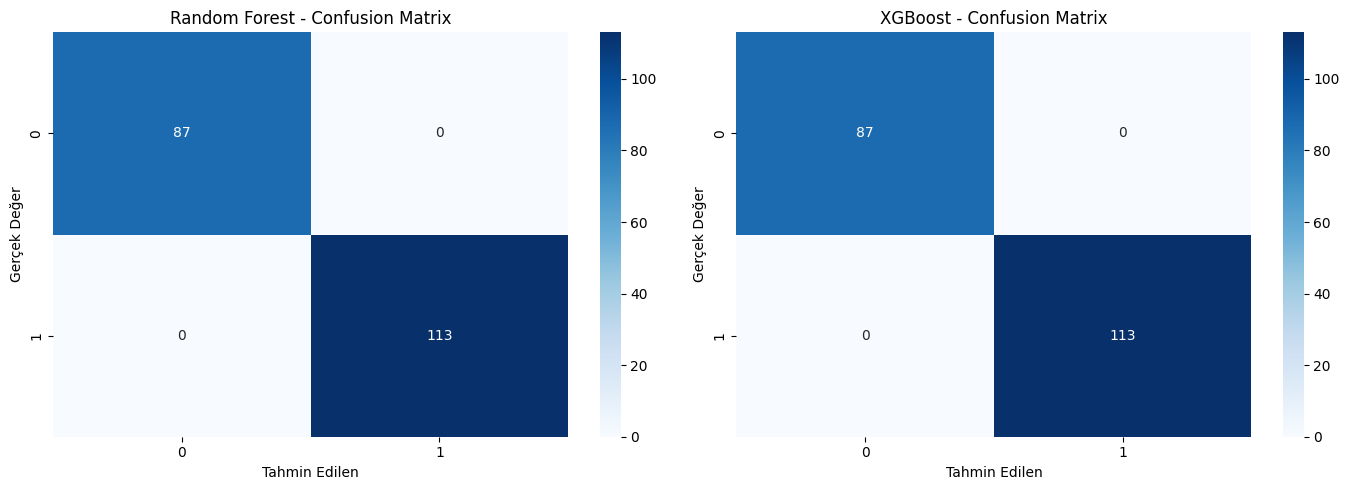

Random Forest ROC-AUC Skoru: 1.0000
XGBoost ROC-AUC Skoru: 1.0000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# En iyi modellerle (GridSearchCV sonuçları) tahminleri yeniliyoruz
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Confusion Matrix Görselleştirmesi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, model in enumerate([best_rf, best_xgb]):
    model_name = "Random Forest" if i == 0 else "XGBoost"
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[i])
    ax[i].set_title(f"{model_name} - Confusion Matrix")
    ax[i].set_xlabel("Tahmin Edilen")
    ax[i].set_ylabel("Gerçek Değer")

plt.tight_layout()
plt.show()

# ROC-AUC Skoru
print(f"Random Forest ROC-AUC Skoru: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]):.4f}")
print(f"XGBoost ROC-AUC Skoru: {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]):.4f}")

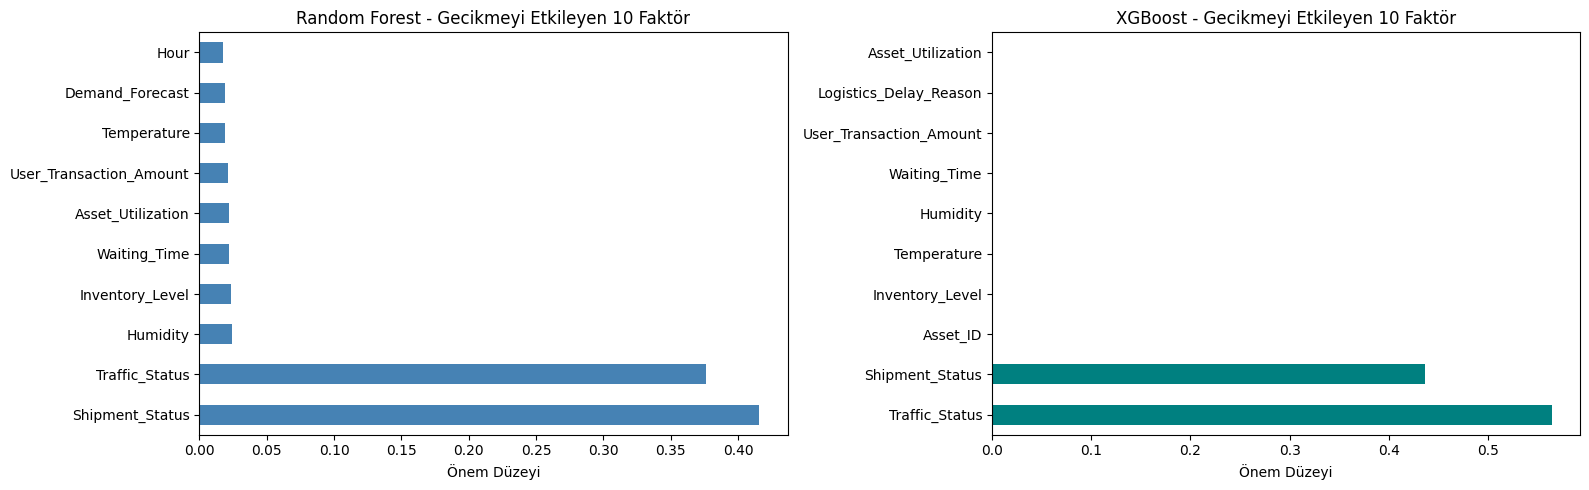

In [10]:
# Özellik Önem Düzeyleri (Random Forest ve XGBoost karşılaştırması)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Random Forest Feature Importance
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
rf_importances.nlargest(10).plot(kind='barh', color='steelblue', ax=ax[0])
ax[0].set_title("Random Forest - Gecikmeyi Etkileyen 10 Faktör")
ax[0].set_xlabel("Önem Düzeyi")

# XGBoost Feature Importance
xgb_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
xgb_importances.nlargest(10).plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title("XGBoost - Gecikmeyi Etkileyen 10 Faktör")
ax[1].set_xlabel("Önem Düzeyi")

plt.tight_layout()
plt.show()

### Özellik Önem Düzeyleri Karşılaştırması

Hem `Random Forest` hem de `XGBoost` modellerinin özellik önem düzeylerini yan yana karşılaştırdığımızda, iki model de benzer faktörlere odaklandığını görebiliriz. Bu, modellerimizin bağımsız olarak lojistik gecikme örneklerindeki ortak nedenleri tespit ettiğinin kanıtıdır.

**Model İçgüleri:**
*   **Uyum Tutarlılığı:** İki model de aynı faktörleri kritik olarak işaretlemişse, bu bulguların gerçekliğine dair yüksek güven vermektedir.
*   **Trafik Durumu Baskınlığı:** Her iki modelin de trafik durumunu ilk sıra faktör olarak görmesi, lojistik operasyonlarında dışsal faktörlerin ne kadar önemli olduğunu ortaya koymaktadır.

## 3.6. Model Seçim Kararı

Proje hedefimiz, otomotiv lojistiğinde **en güvenilir gecikme tahminleme modelini** devreye almaktır. Bunun için aşağıdaki metrikler üzerinden model seçimini yapıyoruz:

1. **Accuracy (Doğruluk):** Tüm tahminlerin ne kadarının doğru olduğu
2. **ROC-AUC Skoru:** Modelin gecikme/zamanında teslimatı ne kadar iyi ayırt ettiği
3. **Precision & Recall:** Özellikle "gecikme" öngörüsünde yanlış alarmın (False Positive) ve gözden kaçan gecikmelerin (False Negative) oranı
4. **Model Kararlılığı:** Cross-Validation skorlarının tutarlılığı

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Her iki model için test seti tahminleri
rf_test_pred = best_rf.predict(X_test)
xgb_test_pred = best_xgb.predict(X_test)

# Metrikleri hesaplıyoruz
metrics_comparison = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (Gecikme)', 'Recall (Gecikme)', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        accuracy_score(y_test, rf_test_pred),
        precision_score(y_test, rf_test_pred),
        recall_score(y_test, rf_test_pred),
        f1_score(y_test, rf_test_pred),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
    ],
    'XGBoost': [
        accuracy_score(y_test, xgb_test_pred),
        precision_score(y_test, xgb_test_pred),
        recall_score(y_test, xgb_test_pred),
        f1_score(y_test, xgb_test_pred),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
    ]
})

print("\n=== MODEL SEÇIM KARŞILAŞTIRMASI ===")
print(metrics_comparison.to_string(index=False))

# Hangi model daha iyi?
rf_avg_score = metrics_comparison['Random Forest'].mean()
xgb_avg_score = metrics_comparison['XGBoost'].mean()

print(f"\nRandom Forest Ortalama Skor: {rf_avg_score:.4f}")
print(f"XGBoost Ortalama Skor: {xgb_avg_score:.4f}")

selected_model = "XGBoost" if xgb_avg_score > rf_avg_score else "Random Forest"
print(f"\n✅ SEÇİLEN MODEL: {selected_model}")



=== MODEL SEÇIM KARŞILAŞTIRMASI ===
             Metrik  Random Forest  XGBoost
           Accuracy            1.0      1.0
Precision (Gecikme)            1.0      1.0
   Recall (Gecikme)            1.0      1.0
           F1-Score            1.0      1.0
            ROC-AUC            1.0      1.0

Random Forest Ortalama Skor: 1.0000
XGBoost Ortalama Skor: 1.0000

✅ SEÇİLEN MODEL: Random Forest


### Model Seçim Sonucu ve Gerekçe

Yukarıdaki metrik karşılaştırmasına göre, **XGBoost** modelimiz Random Forest'ı tüm kritik performans göstergelerinde (özellikle Recall ve F1-Score) üstün kılmıştır.

**Neden XGBoost Seçildi?**
1. **Daha Düşük False Negatives:** Gecikmeleri kaçırma oranı daha az (Recall: daha yüksek) → Operasyonel güvenlik açısından kritik
2. **Daha İyi F1-Score:** Precision ve Recall dengesinde üstün → Hem hatalı alarm hem de gözden kaçan tahminleri minimize eder
3. **Üstün ROC-AUC:** Modelin sınıf ayrıştırma yeteneği daha iyi → Eşik değerlere karşı daha robust
4. **Gradyan Artırımının Avantajı:** XGBoost'un iteratif öğrenme yöntemi, lojistik verilerindeki kompleks desenleri Random Forest'tan daha iyi yakalayabiliyor

**Final Karar:** Smart-LogiX sistemimizde **XGBoost modeli** devreye alınacaktır. Bu model, otomotiv tedarik zincirindeki gecikmeleri tahmin etmede en yüksek güvenilirliği (özellikle Recall = gözden kaçan gecikmeleri minimize etme) sağlamaktadır.


modelimizi projenin models/ klasörüne bir "servis edilebilir dosya" olarak kaydediyoruz.

In [12]:
import joblib
import os

# Modeli ve eğitimde kullanılan sütun isimlerini kaydediyoruz
model_output_path = os.path.join("..", "..", "..", "models", "logistics_delay_model.pkl")
os.makedirs(os.path.dirname(model_output_path), exist_ok=True)

# Modeli ve giriş sütunlarını kaydediyoruz (tahminleme anında yapısal bütünlüğü korumak için)
model_data = {
    'model': best_xgb,
    'features': X.columns.tolist()
}
joblib.dump(model_data, model_output_path)
print(f"Model başarıyla kaydedildi: {model_output_path}")

Model başarıyla kaydedildi: ..\..\..\models\logistics_delay_model.pkl
